# Plot $R_0$ dependence on specific humidity and data in Australia
## From MERRA-2/SIRS model
* HCoV-HKU1 parameters
* weekly resolution
* monthly ENSO composites => Oct-Nov-Dec average (OND)

Last updated Dec 6 2024 to show world maps instead of only Australia

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
# climate dependence parameters for HCoV-HKU1 (human coronavirus)

climdepens ={
    'HKU1': dict(a=-227.5, R0_min=1.5, R0_max=2.5)}

def q2R0(q, a, R0_min, R0_max):
    '''R0 dependence on climate (specific humidity)'''
    R0 = (R0_max - R0_min) * np.exp(a*q) + R0_min
    if isinstance(R0, xr.DataArray):
        R0.name = 'R0'
    
    return R0

# Plot specific humidity and $R_0$ El Niño anomaly

In [8]:
# select australia only

# def get_Australia(ds):
#     # 110-155E
#     # 10-45S
#     return ds.sel(longitude = slice(110,155), latitude = slice(-45,-8))

def get_monthlydata(ds):
    return ds.resample(time="ME").mean(dim='time')

def get_ENSOyrs():
    import pandas as pd
    # import ENSO years 
    df=pd.read_csv('./ENSO_yrs_final.csv', index_col=0)
    ds = df.to_xarray()
    # Convert the array to boolean array
    ds = ds.astype(bool)
    return ds

def ENSO_comp(HKU1, comp_types):
    
    ENSOds = get_ENSOyrs()
    from tqdm.notebook import tqdm
    
    comp_ds = xr.Dataset()
    
    for ii in tqdm(range(np.size(comp_types))):

        composite_type = comp_types[ii]

        # get event years
        event_years = ENSOds.year[ENSOds[composite_type]]

        # get years from data.TIME
        years_array = pd.DatetimeIndex(HKU1.time).year

        # for each year in the list, find the events_all from that year
        included_bool_array = [year in event_years for year in years_array]

        # get all the events from the data
        events_all = HKU1.isel(time=included_bool_array)

        # put into year/month format
        for ii in range(event_years.size):
            # get data from that year
            data_monthly = events_all.isel(time=slice(ii*12,ii*12+12))
            #print(data_temp)

            data_monthly = data_monthly.rename({'time': 'month'})
            data_monthly['month'] = np.arange(1, 13)

            data_monthly = data_monthly.assign_coords(year=event_years[ii])

            if ii == 0:
                events_yearmonth = data_monthly
            else:
                events_yearmonth = xr.concat([events_yearmonth,data_monthly], dim='year')

        # compute composite
        comp = events_yearmonth.mean('year')
        
        comp_ds[composite_type] = comp
    

    return comp_ds
        #events_yearmonth.to_netcdf(f"./data_{res}/ENSO_HKU1_{composite_type}_allevents.nc")
        #comp.to_netcdf(f"./data_{res}/ENSO_HKU1_{composite_type}_composite.nc")



In [10]:
# load q data
q = xr.open_dataarray('./SIRSmodel_input/MERRA2.1981-2017.QV2M.weekly.nc')
#q = get_Australia(q)
q

<xarray.DataArray 'QV2M' (time: 13508, latitude: 361, longitude: 576)> Size: 11GB
[2808799488 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 108kB 1981-01-04T12:00:00 ... 2017-12-28...
  * longitude  (longitude) float64 5kB -180.0 -179.4 -178.8 ... 178.8 179.4
  * latitude   (latitude) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 89.0 89.5 90.0
Attributes:
    standard_name:   2-meter_specific_humidity
    long_name:       2-meter_specific_humidity
    units:           kg kg-1
    fmissing_value:  1000000000000000.0
    vmax:            1000000000000000.0
    vmin:            -1000000000000000.0

In [12]:
# load R0 data
R0 = xr.open_dataarray('./SIRSmodel_input/HKU1_MERRA2_weekly_R0.nc')
#R0 = get_Australia(R0)

In [13]:
# get monthly data
q_mm = get_monthlydata(q)
R0_mm = get_monthlydata(R0)

In [14]:
# compute climatology
clim_q = q_mm.groupby('time.month').mean('time')
clim_R0 = R0_mm.groupby('time.month').mean('time')

In [15]:
# compute ENSO composites
import pandas as pd
comp_q = ENSO_comp(q_mm,['ElNino','LaNina'])
comp_R0 = ENSO_comp(R0_mm,['ElNino','LaNina'])

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

In [16]:
comp_q

<xarray.Dataset> Size: 20MB
Dimensions:    (longitude: 576, latitude: 361, month: 12)
Coordinates:
  * longitude  (longitude) float64 5kB -180.0 -179.4 -178.8 ... 178.8 179.4
  * latitude   (latitude) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 89.0 89.5 90.0
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    ElNino     (month, latitude, longitude) float32 10MB 0.000387 ... 0.0004994
    LaNina     (month, latitude, longitude) float32 10MB 0.0003786 ... 0.0005832

## Plot

In [17]:
q_arr = np.arange(0.0001,0.02,0.001)
R0_HKU1 = q2R0(q_arr, **climdepens['HKU1'])

Text(0.66, 0.95, 'El Niño anomaly (Year 0, OND)')

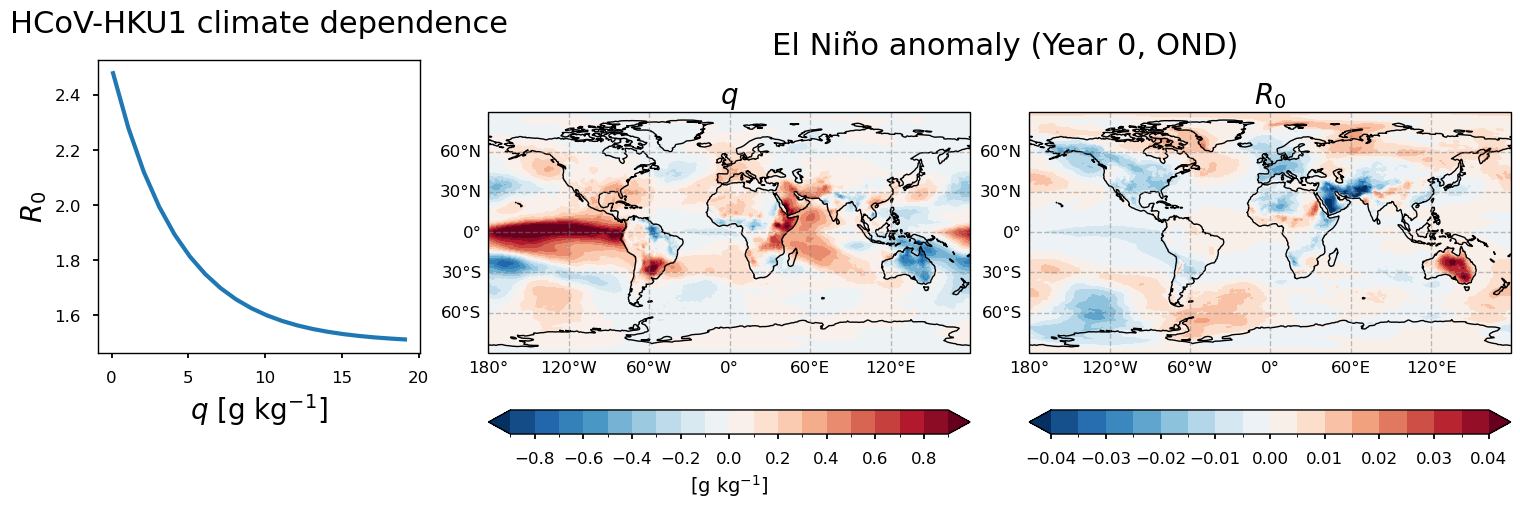

In [27]:
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

plt.style.use('/tigress/mvchung/ANALYSIS/func/PPT.mplstyle')

fig = plt.figure(figsize=(15, 5), constrained_layout=True)
# Define a GridSpec with 1 row and 3 columns; make the first column narrower
gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 1.5, 1.5])

# First subplot (standard plot)
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(q_arr * 1000, R0_HKU1, label='HKU1', linewidth=3)
ax0.set_xlabel('$q$ [g kg$^{-1}$]', fontsize=20)
ax0.set_ylabel('$R_0$', fontsize=20)
ax0.set_title('HCoV-HKU1 climate dependence', fontsize=22, pad=20)

# Second subplot with PlateCarree projection
ax1 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
q_anom = comp_q['ElNino'].sel(month=slice(10, 12)).mean('month') - clim_q.sel(month=slice(10, 12)).mean('month')
cf1 = (1000 * q_anom).plot.contourf(
    ax=ax1, cmap='RdBu_r', transform=ccrs.PlateCarree(),
    levels=np.arange(-0.9, 1, 0.1), extend='both'
)
ax1.set_title('$q$', fontsize=20)
ax1.coastlines()
gridlines1 = ax1.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
gridlines1.top_labels = False
gridlines1.right_labels = False
cf1.colorbar.remove()
cb1 = fig.colorbar(cf1, ax=ax1, orientation='horizontal', pad=-0.05)
cb1.set_label('[g kg$^{-1}$]')

# Third subplot with PlateCarree projection
ax2 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
R0_anom = comp_R0['ElNino'].sel(month=slice(10, 12)).mean('month') - clim_R0.sel(month=slice(10, 12)).mean('month')
cf2 = R0_anom.plot.contourf(
    ax=ax2, cmap='RdBu_r', transform=ccrs.PlateCarree(),
    levels=np.arange(-0.04, 0.045, 0.005), extend='both'
)
ax2.set_title('$R_0$', fontsize=20)
ax2.coastlines()
gridlines2 = ax2.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
gridlines2.top_labels = False
gridlines2.right_labels = False
cf2.colorbar.remove()
cb2 = fig.colorbar(cf2, ax=ax2, orientation='horizontal', pad=-0.05)

# Set the overall title
fig.suptitle('El Niño anomaly (Year 0, OND)', x=0.66, y=0.95, fontsize=22)
